Shape of Dataset: (768, 9)

Columns:
Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

Data Types:
Pregnancies                   int64
Glucose                       int64
BloodPressure               float64
SkinThickness                 int64
Insulin                     float64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

First 5 Records:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148           72.0             35    169.5  33.6   
1            1       85           66.0             29    102.5  26.6   
2            8      183           64.0             32    169.5  23.3   
3            1       89           66.0             23     94.0  28.1   
4            0      137           40.0             35    168.0  43.1   



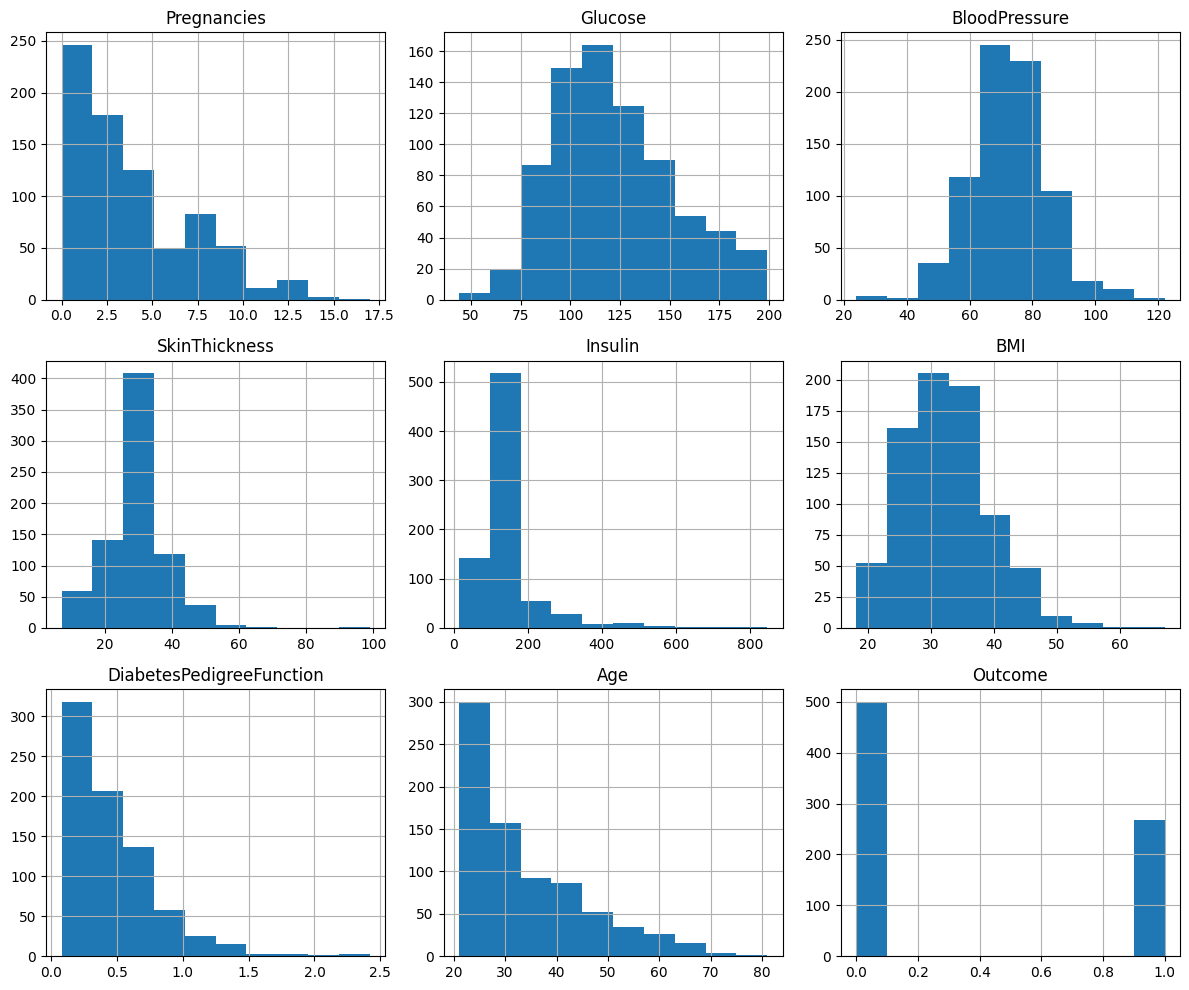

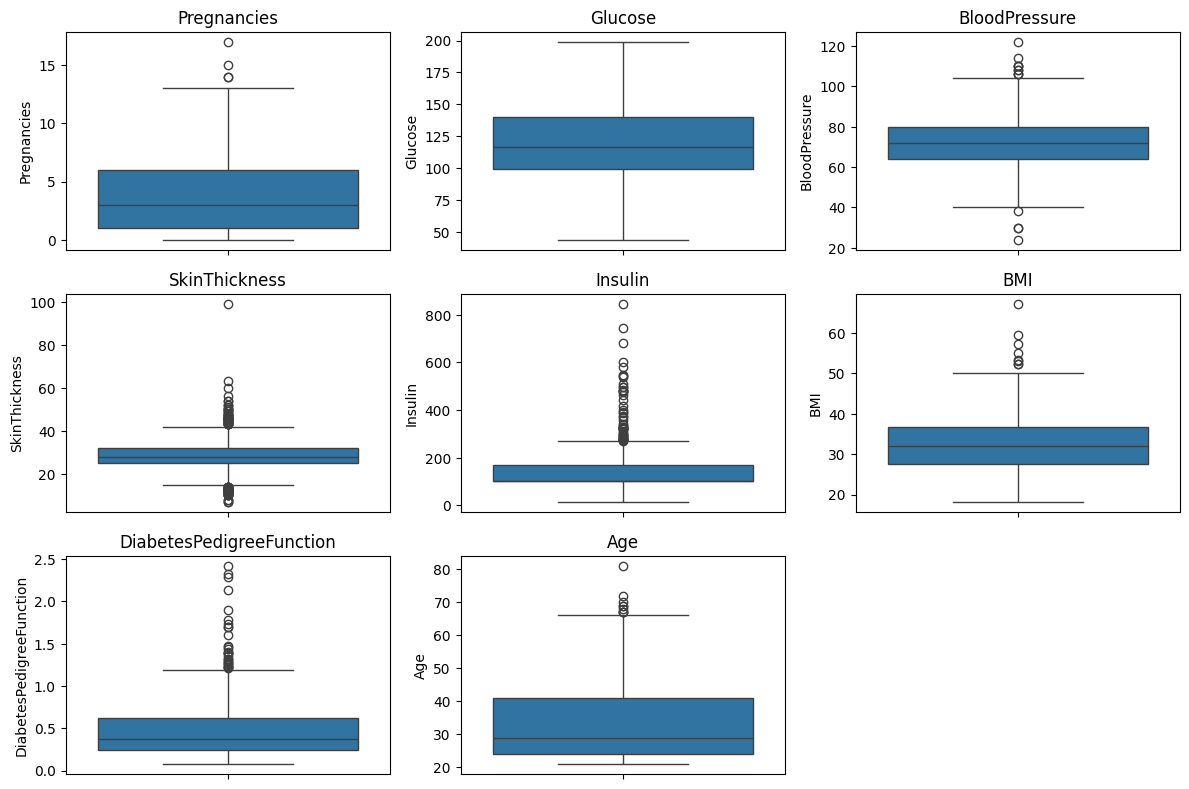

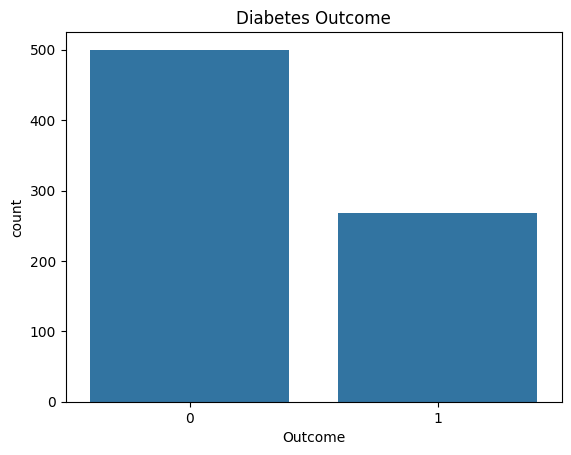

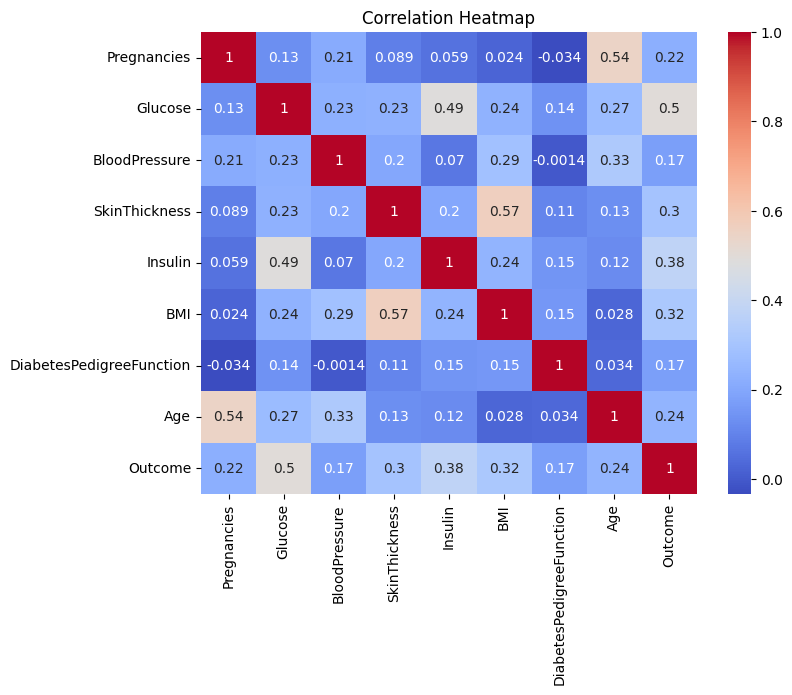

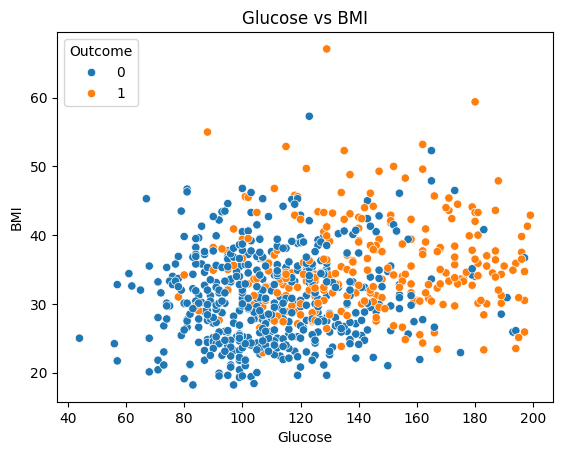

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("diabetes.csv")

# Shape of dataset
print("Shape of Dataset:", df.shape)

# Column names
print("\nColumns:")
print(df.columns)

# Data types
print("\nData Types:")
print(df.dtypes)

# First 5 records
print("\nFirst 5 Records:")
print(df.head())

# Numerical variables
print("\nNumerical Variables:")
for col in df.columns:
    if df[col].nunique() > 2:
        print("-", col)

# Binary variable
print("\nBinary Variable:")
print("Outcome")

# Statistical summary
print("\nStatistical Summary:")
print(df.describe())

# Median
print("\nMedian:")
print(df.median(numeric_only=True))

# Variance
print("\nVariance:")
print(df.var(numeric_only=True))

# Standard deviation
print("\nStandard Deviation:")
print(df.std(numeric_only=True))

# Missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Zero values in important columns
print("\nZero Values in Important Columns:")

columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

for col in columns:
    print(col, ":", (df[col] == 0).sum())

# Possible outliers using IQR method
print("\nPossible Outliers (IQR Method):")

for col in df.columns[:-1]:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(col, ":", len(outliers))

# Histograms
df.hist(figsize=(12, 10))
plt.tight_layout()
plt.show()

# Boxplots
plt.figure(figsize=(12, 8))

for i, col in enumerate(df.columns[:-1]):
    plt.subplot(3, 3, i + 1)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

# Diabetes outcome count
sns.countplot(x="Outcome", data=df)
plt.title("Diabetes Outcome")
plt.show()

# Correlation heatmap
plt.figure(figsize=(8, 6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

# Scatter plot
sns.scatterplot(
    data=df,
    x="Glucose",
    y="BMI",
    hue="Outcome"
)

plt.title("Glucose vs BMI")
plt.show()